# NumPy 프로젝트 - 실전 문제 해결

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib
import platform

# 한국어 폰트 설정
system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'

# 음수 기호 표시
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 기초 프로젝트: 학생 성적 분석

**문제:** 5개 과목의 학생 성적을 분석하고 통계를 계산하세요.

학생별 평균 성적:
학생1: 88.40점
학생2: 89.20점
학생3: 80.80점
학생4: 94.00점
학생5: 78.40점

과목별 평균 성적:
수학: 86.00점
영어: 85.40점
과학: 86.00점
사회: 88.00점
국어: 85.40점

전체 평균:
86.16점

과목별 표준편차:
수학: 6.60
영어: 6.18
과학: 6.07
사회: 5.18
국어: 6.37

성적 최고/최저:
최고점: 96점
최저점: 75점

90점 이상: 10개
80점 미만: 5개


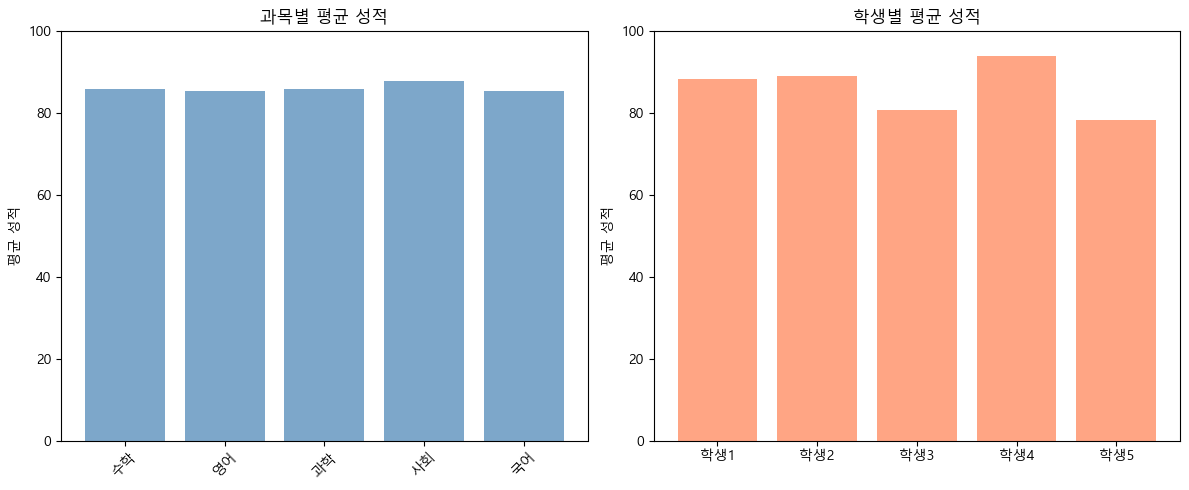

In [2]:
# 학생 성적 데이터 (5개 과목)
scores = np.array([
    [85, 90, 88, 92, 87],  # 학생1
    [92, 88, 90, 85, 91],  # 학생2
    [78, 82, 80, 85, 79],  # 학생3
    [95, 92, 94, 96, 93],  # 학생4
    [80, 75, 78, 82, 77]   # 학생5
])

subjects = ['수학', '영어', '과학', '사회', '국어']

print('학생별 평균 성적:')
student_means = np.mean(scores, axis=1)
for i, mean in enumerate(student_means, 1):
    print(f'학생{i}: {mean:.2f}점')

print('\n과목별 평균 성적:')
subject_means = np.mean(scores, axis=0)
for subj, mean in zip(subjects, subject_means):
    print(f'{subj}: {mean:.2f}점')

print('\n전체 평균:')
total_mean = np.mean(scores)
print(f'{total_mean:.2f}점')

print('\n과목별 표준편차:')
subject_std = np.std(scores, axis=0)
for subj, std in zip(subjects, subject_std):
    print(f'{subj}: {std:.2f}')

print('\n성적 최고/최저:')
print(f'최고점: {np.max(scores)}점')
print(f'최저점: {np.min(scores)}점')

# 90점 이상인 성적 개수
high_scores = np.sum(scores >= 90)
print(f'\n90점 이상: {high_scores}개')

# 80점 미만인 학생
low_students = np.sum(scores < 80)
print(f'80점 미만: {low_students}개')

# 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
x = np.arange(len(subjects))
plt.bar(x, subject_means, alpha=0.7, color='steelblue')
plt.xticks(x, subjects, rotation=45)
plt.ylabel('평균 성적')
plt.title('과목별 평균 성적')
plt.ylim(0, 100)

plt.subplot(1, 2, 2)
students = [f'학생{i}' for i in range(1, 6)]
plt.bar(students, student_means, alpha=0.7, color='coral')
plt.ylabel('평균 성적')
plt.title('학생별 평균 성적')
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('results/numpy_4_59.png', dpi=300, bbox_inches='tight')
plt.show()

# 중급 프로젝트: 주식 가격 분석 및 포트폴리오

**문제:** 3개 주식의 월별 가격 변동을 분석하고 최적 투자 비율을 찾으세요.

월별 수익률 (%)
Stock A: [-0.69132151  3.23844269  7.61514928 -1.17076687 -1.17068478  7.89606408
  3.83717365 -2.34737193  2.71280022 -2.31708846 -2.32864877]
Stock B: [-15.30624196 -13.79934266  -4.49830023  -8.10264896   2.51397866
  -7.2641926  -11.29842961  11.72519015  -1.8062104    0.54022564
 -11.39798549]
Stock C: [ 0.33276777 -3.45298073  1.12709406 -1.80191607 -0.87508125 -1.80511984
  5.55683455 -0.04049167 -3.17313279  2.46763474 -3.66253095]

통계:
Stock A:
  평균 수익률: 1.39%
  표준편차 (리스크): 3.71%
  총 수익률: 15.54%
Stock B:
  평균 수익률: -5.34%
  표준편차 (리스크): 7.72%
  총 수익률: -47.20%
Stock C:
  평균 수익률: -0.48%
  표준편차 (리스크): 2.67%
  총 수익률: -5.57%

상관계수 행렬:
[[ 1.         -0.28011898  0.08325999]
 [-0.28011898  1.          0.0887825 ]
 [ 0.08325999  0.0887825   1.        ]]


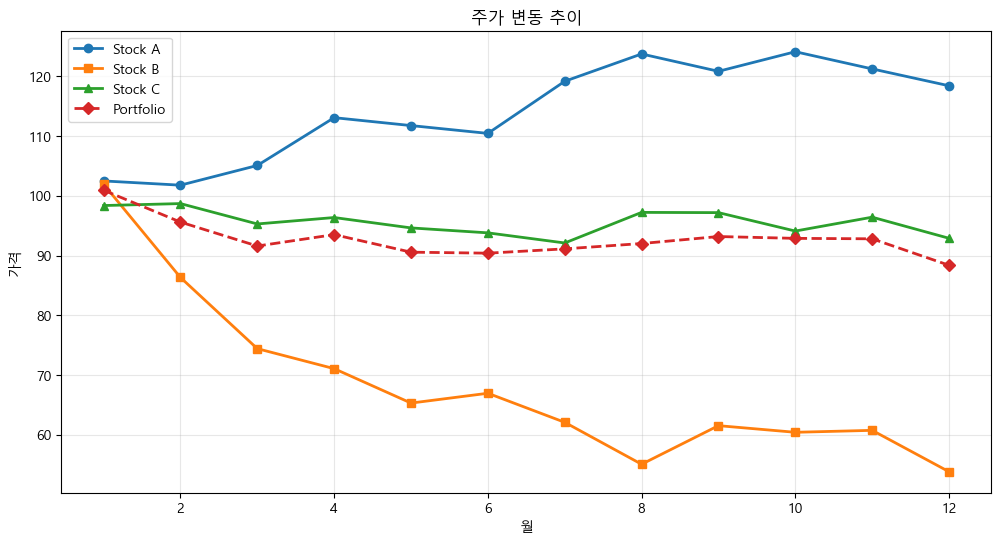

In [3]:
# 12개월 주가 데이터
np.random.seed(42)
months = np.arange(1, 13)

# 각 주식의 월별 가격 (초기: 100)
stock_a = 100 * np.cumprod(1 + np.random.randn(12) * 0.05)  # 변동성 5%
stock_b = 100 * np.cumprod(1 + np.random.randn(12) * 0.08)  # 변동성 8%
stock_c = 100 * np.cumprod(1 + np.random.randn(12) * 0.03)  # 변동성 3%

stocks = np.array([stock_a, stock_b, stock_c])
stock_names = ['Stock A', 'Stock B', 'Stock C']

# 수익률 계산
returns = np.diff(stocks, axis=1) / stocks[:, :-1]

print('월별 수익률 (%)')
for i, name in enumerate(stock_names):
    print(f'{name}: {returns[i] * 100}')

print('\n통계:')
for i, name in enumerate(stock_names):
    print(f'{name}:')
    print(f'  평균 수익률: {np.mean(returns[i]) * 100:.2f}%')
    print(f'  표준편차 (리스크): {np.std(returns[i]) * 100:.2f}%')
    print(f'  총 수익률: {(stocks[i, -1] - stocks[i, 0]) / stocks[i, 0] * 100:.2f}%')

# 상관계수 계산
corr_matrix = np.corrcoef(returns)
print('\n상관계수 행렬:')
print(corr_matrix)

# 포트폴리오 (동일 비율 투자)
portfolio = np.mean(stocks, axis=0)

plt.figure(figsize=(12, 6))
plt.plot(months, stock_a, marker='o', label='Stock A', linewidth=2)
plt.plot(months, stock_b, marker='s', label='Stock B', linewidth=2)
plt.plot(months, stock_c, marker='^', label='Stock C', linewidth=2)
plt.plot(months, portfolio, marker='D', label='Portfolio', linewidth=2, linestyle='--')
plt.xlabel('월')
plt.ylabel('가격')
plt.title('주가 변동 추이')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('results/numpy_7_39.png', dpi=300, bbox_inches='tight')
plt.show()

# 상급 프로젝트: 이미지 필터링 및 처리

**문제:** 디지털 이미지에 여러 필터를 적용하고 효과를 비교하세요.

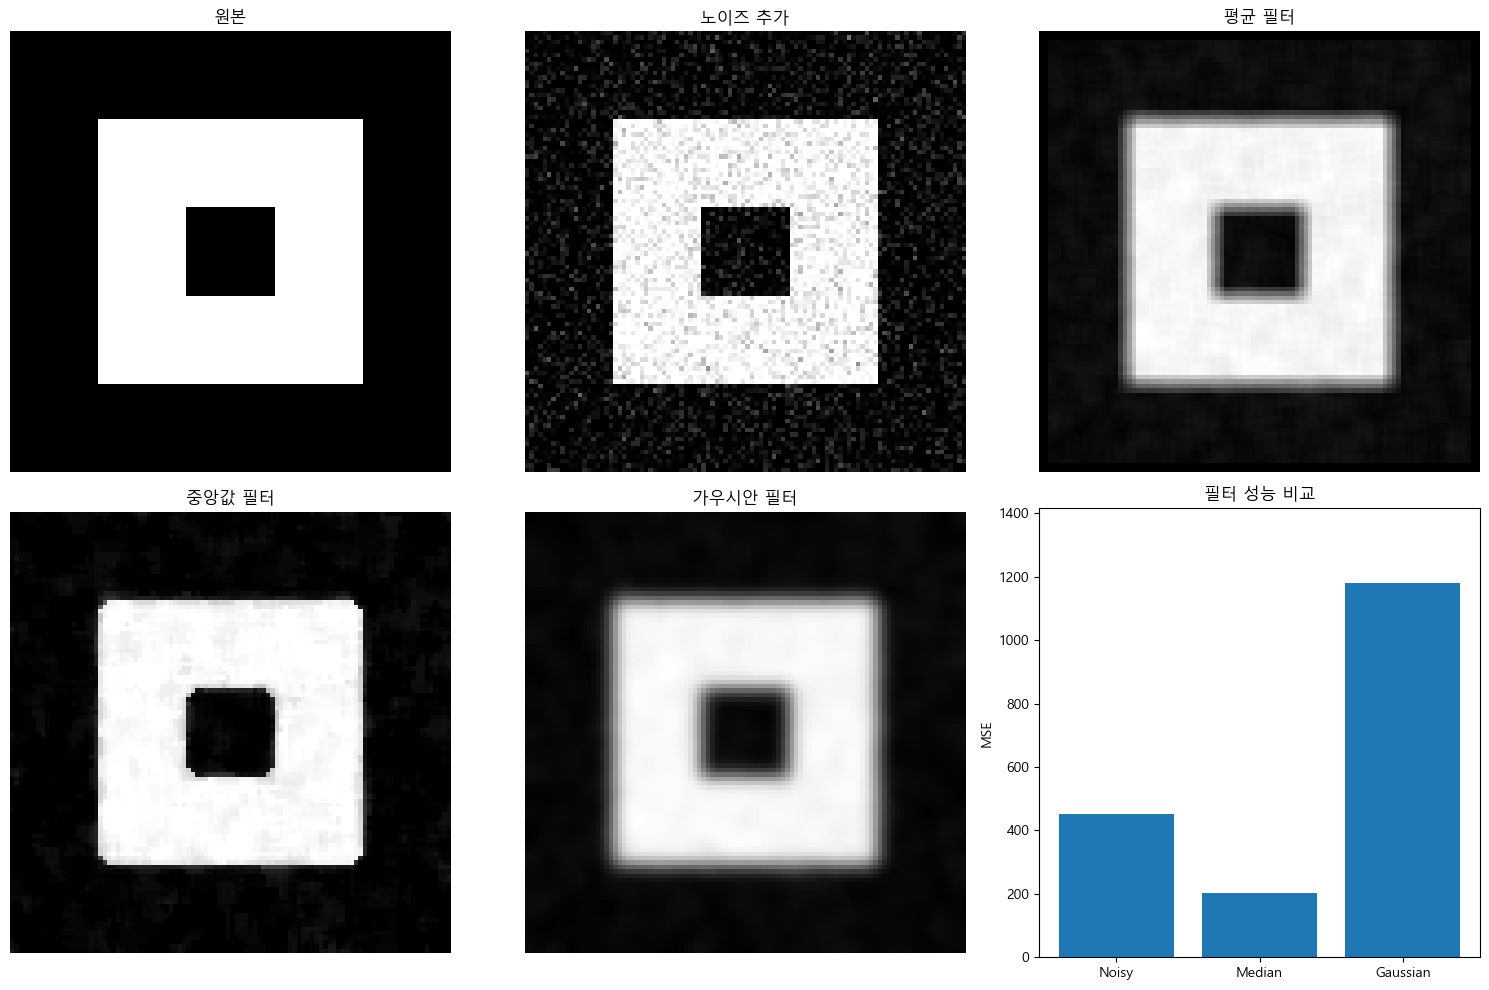

MSE (노이즈): 453.17
MSE (중앙값 필터): 202.86
MSE (가우시안 필터): 1179.37


In [4]:
# 합성 이미지 생성 (간단한 패턴)
image = np.zeros((100, 100))
image[20:80, 20:80] = 255  # 흰 사각형
image[40:60, 40:60] = 0    # 검은 사각형

# 노이즈 추가
noise = np.random.normal(0, 30, image.shape)
noisy_image = np.clip(image + noise, 0, 255).astype(int)

# 필터 1: 평균 필터 (블러)
kernel_avg = np.ones((5, 5)) / 25
blurred = np.zeros_like(image)
for i in range(2, 98):
    for j in range(2, 98):
        region = noisy_image[i-2:i+3, j-2:j+3]
        blurred[i, j] = np.mean(region)

# 필터 2: 중앙값 필터 (노이즈 제거)
from scipy.ndimage import median_filter
median_filtered = median_filter(noisy_image, size=5)

# 필터 3: 가우시안 필터
from scipy.ndimage import gaussian_filter
gaussian_filtered = gaussian_filter(noisy_image, sigma=2)

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('원본')
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy_image, cmap='gray')
axes[0, 1].set_title('노이즈 추가')
axes[0, 1].axis('off')

axes[0, 2].imshow(blurred, cmap='gray')
axes[0, 2].set_title('평균 필터')
axes[0, 2].axis('off')

axes[1, 0].imshow(median_filtered, cmap='gray')
axes[1, 0].set_title('중앙값 필터')
axes[1, 0].axis('off')

axes[1, 1].imshow(gaussian_filtered, cmap='gray')
axes[1, 1].set_title('가우시안 필터')
axes[1, 1].axis('off')

# MSE 계산 (원본과의 차이)
mse_noisy = np.mean((image - noisy_image)**2)
mse_median = np.mean((image - median_filtered)**2)
mse_gaussian = np.mean((image - gaussian_filtered)**2)

axes[1, 2].bar(['Noisy', 'Median', 'Gaussian'], [mse_noisy, mse_median, mse_gaussian])
axes[1, 2].set_ylabel('MSE')
axes[1, 2].set_title('필터 성능 비교')
axes[1, 2].set_ylim(0, max(mse_noisy, mse_median, mse_gaussian) * 1.2)

plt.tight_layout()
plt.show()

print(f'MSE (노이즈): {mse_noisy:.2f}')
print(f'MSE (중앙값 필터): {mse_median:.2f}')
print(f'MSE (가우시안 필터): {mse_gaussian:.2f}')

# 고급 프로젝트: 신경망 기초 (Forward Propagation)

**문제:** NumPy를 사용하여 간단한 신경망을 구현하고 학습 과정을 시뮬레이션하세요.

Epoch 50/200, Loss: 0.6880
Epoch 100/200, Loss: 0.4908
Epoch 150/200, Loss: 0.2094
Epoch 200/200, Loss: 0.0483

예측 결과:
[0 0] -> 0.0298
[0 1] -> 0.8728
[1 0] -> 0.9800
[1 1] -> 0.0173


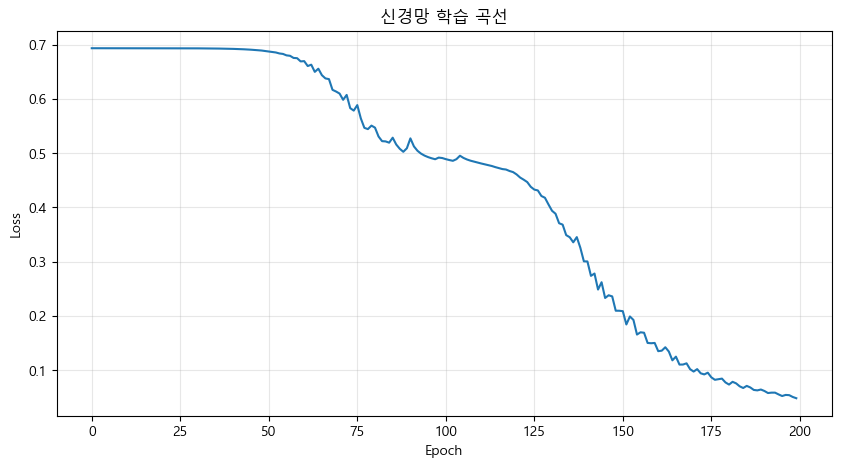

In [5]:
# 활성화 함수
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

# 신경망 클래스
class SimpleNeuralNetwork:
    def __init__(self, layer_sizes):
        self.layer_sizes = layer_sizes
        self.weights = []
        self.biases = []
        self.losses = []
        
        # 가중치 초기화
        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(w)
            self.biases.append(b)
    
    def forward(self, X):
        self.activations = [X]
        self.z_values = []
        
        for i in range(len(self.weights)):
            z = np.dot(self.activations[-1], self.weights[i]) + self.biases[i]
            self.z_values.append(z)
            
            # 마지막 층은 시그모이드, 나머지는 ReLU
            if i == len(self.weights) - 1:
                a = sigmoid(z)
            else:
                a = relu(z)
            
            self.activations.append(a)
        
        return self.activations[-1]
    
    def backward(self, X, y, learning_rate):
        m = X.shape[0]
        
        # 출력층 에러
        delta = self.activations[-1] - y
        
        # 역전파
        for i in range(len(self.weights) - 1, -1, -1):
            dW = np.dot(self.activations[i].T, delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m
            
            if i > 0:
                delta = np.dot(delta, self.weights[i].T)
                delta *= relu_derivative(self.activations[i])
            
            self.weights[i] -= learning_rate * dW
            self.biases[i] -= learning_rate * db
    
    def train(self, X, y, epochs, learning_rate):
        for epoch in range(epochs):
            output = self.forward(X)
            loss = -np.mean(y * np.log(np.clip(output, 1e-10, 1)) + 
                            (1 - y) * np.log(np.clip(1 - output, 1e-10, 1)))
            self.losses.append(loss)
            self.backward(X, y, learning_rate)
            
            if (epoch + 1) % 50 == 0:
                print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}')
    
    def predict(self, X):
        return self.forward(X)

# 데이터 생성 (XOR 문제)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# 신경망 학습
nn = SimpleNeuralNetwork([2, 4, 1])
nn.train(X, y, epochs=200, learning_rate=1.0)

# 예측
predictions = nn.predict(X)
print('\n예측 결과:')
for inp, pred in zip(X, predictions):
    print(f'{inp} -> {pred[0]:.4f}')

# 손실 함수 시각화
plt.figure(figsize=(10, 5))
plt.plot(nn.losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('신경망 학습 곡선')
plt.grid(alpha=0.3)
plt.savefig('results/numpy_13_99.png', dpi=300, bbox_inches='tight')
plt.show()